In [1]:
import anndata as ad
import scanpy as sc
import numpy as np
import random
import plotly.express as px
import pandas as pd

In [2]:
adata = ad.read_h5ad("merged.h5ad")
adata.obs

,perturbation,efficiency,dataset,eff_score,perturbation_type,cls_label,split
AAACCAATCATTAGTCAACGGGAA-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,EIF1,1.530678,Marson2025_D1_Rest,1.527950,CRISPRi,EIF1,train
AAAGTCATCGCGTTACACTTTAGG-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,PSMB5,2.852200,Marson2025_D1_Rest,2.834641,CRISPRi,PSMB5,val
AACCAACAGAGCAACTAACGGGAA-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,ANKRD11,-0.138770,Marson2025_D1_Rest,0.138768,CRISPRi,ANKRD11,val
AACCCGGCAATGTTCCACTTTAGG-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,PTMA,3.128171,Marson2025_D1_Rest,3.105041,CRISPRi,PTMA,train
AAGACAACACTATCACATGTTGAC-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest,PTMA,2.286528,Marson2025_D1_Rest,2.277457,CRISPRi,PTMA,train
...,...,...,...,...,...,...,...
ATAACACTCACGCGTG-HEK293T_Batch84;XAtlas2025_HEK293T,control,0.000000,XAtlas2025_HEK293T,0.000000,CRISPRi,control,query
GCCAATTCAAAAGCCA-HEK293T_Batch18;XAtlas2025_HEK293T,control,0.000000,XAtlas2025_HEK293T,0.000000,CRISPRi,control,query
CTTCGTTAGATGGGAT-HEK293T_Batch10;XAtlas2025_HEK293T,control,0.000000,XAtlas2025_HEK293T,0.000000,CRISPRi,control,query
ACTAATGGTACAAGGA-HEK293T_Batch158;XAtlas2025_HEK293T,control,0.000000,XAtlas2025_HEK293T,0.000000,CRISPRi,control,query


In [3]:
adata.var

""
A1BG
AACS
AAK1
AAMDC
AAMP
...
ZRANB2-DT
ZSCAN4
ZSWIM2
ZSWIM5


In [5]:
adata.obs["perturbation"].isin(adata.var.index).all()

False

In [6]:
perturbations = set(adata.obs["perturbation"].unique())
var_names = set(adata.var.index)

missing = perturbations - var_names
print(f"Missing from adata.var: {missing}")

Missing from adata.var: {'NFRKB', 'MRPL4', 'RABGGTA', 'EIF2B2', 'MRPS28', 'control', 'MRPL39', 'EXOSC3', 'WTAP', 'SLC39A7', 'ALG14', 'CPSF3', 'PMPCB', 'DDX46', 'UXS1', 'NUDCD3', 'SF3A2', 'RGPD6', 'INO80B', 'MRPL19', 'TARS2', 'INTS8', 'CIAPIN1', 'CNOT3', 'SRP68', 'MRPL38', 'MRPL27', 'EIF2B5', 'MAGOH', 'UPF2', 'SART3', 'CLASRP', 'GRB2', 'MRPS35', 'E4F1', 'TARDBP', 'MED19', 'SMG5', 'ISCA2', 'SETDB1', 'MRPL54', 'SRP72', 'PABPN1', 'CSNK2B', 'MRPS27', 'EIF2B1', 'MRPL35'}


In [3]:
adata.obsm

AxisArrays with keys: ExPert_latent_z_shared

In [4]:
adata.obsm["ExPert_latent_z_shared"]

array([[ 1.68992352e+00, -4.51796246e+00,  4.12199211e+00, ...,
        -2.77662650e-02,  1.16018087e-01,  1.34026915e-01],
       [ 1.02601266e+00,  1.17819178e+00,  4.48840904e+00, ...,
        -6.73262775e-02,  1.81532085e-01,  1.16230212e-01],
       [-3.11678243e+00, -6.26283932e+00, -6.43038702e+00, ...,
        -4.42376733e-03,  1.59544557e-01,  1.76972911e-01],
       ...,
       [-1.42130589e+00, -1.29572010e+00, -2.27478027e+00, ...,
         9.67462882e-02,  1.48747623e-01, -8.69896263e-02],
       [-1.42589223e+00, -1.92594886e-01, -3.48259974e+00, ...,
        -2.59294547e-02,  1.40104741e-01,  1.10121876e-01],
       [-1.25715470e+00, -1.73171282e+00,  6.66929483e-02, ...,
        -1.74319118e-01, -5.19235339e-03,  9.86062512e-02]], dtype=float32)

In [5]:
adata.var

""
A1BG
AACS
AAK1
AAMDC
AAMP
...
ZRANB2-DT
ZSCAN4
ZSWIM2
ZSWIM5


In [6]:
adata.obs["split"].unique()

['train', 'val', 'test', 'ood_test', 'query']
Categories (5, object): ['ood_test', 'query', 'test', 'train', 'val']

### Visualization

In [7]:
import os
os.makedirs("figures", exist_ok=True)

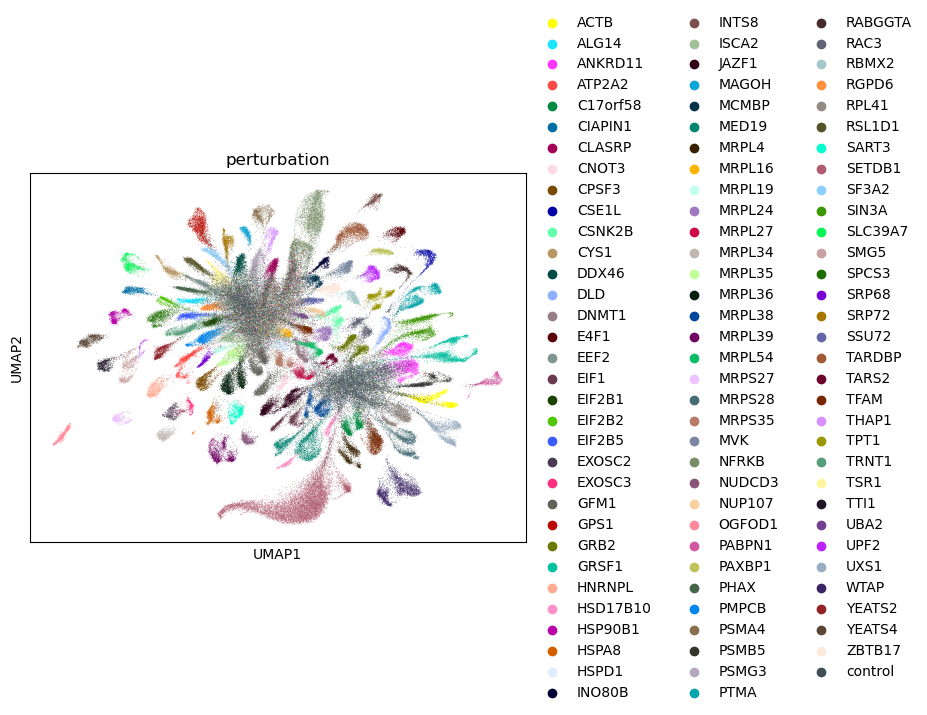

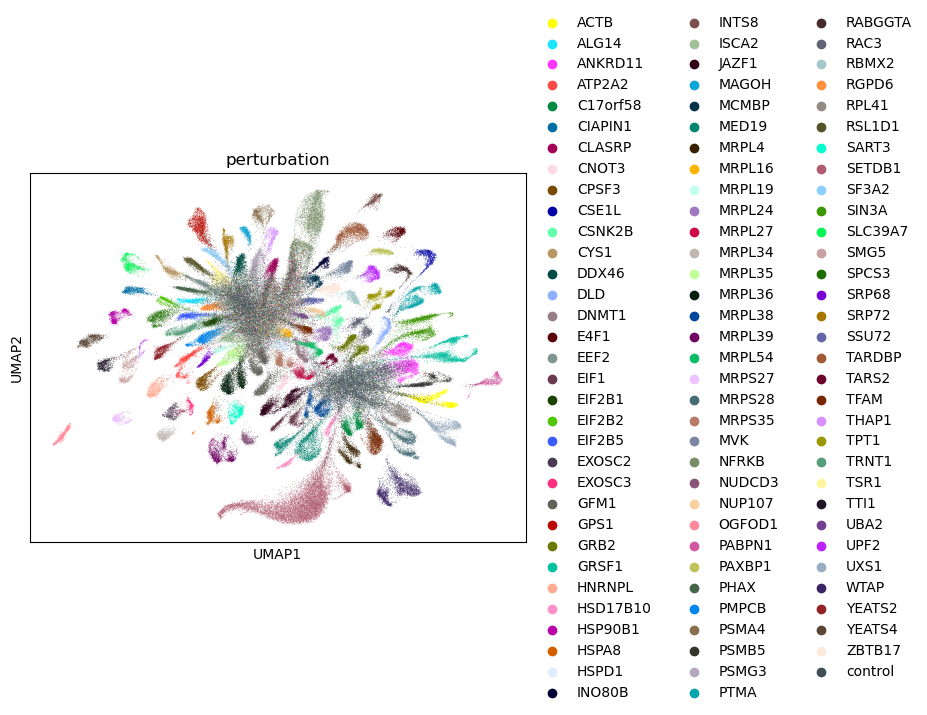

In [10]:
# visualize original data
seed = 42 # change if needed 
np.random.seed(seed)
random.seed(seed)

sc.pp.neighbors(adata, use_rep="ExPert_latent_z_shared")
sc.tl.umap(adata, random_state = seed) 

# Save PNG
sc.pl.umap(
    adata, 
    color="perturbation", 
    save="perturbation_all.png")

# Save SVG
sc.pl.umap(
    adata, 
    color="perturbation", 
    save="perturbation_all.svg")

In [11]:
np.save("figures/umap_all_embedding.npy", adata.obsm["X_umap"])

In [12]:
print(adata.obs.columns)

Index(['perturbation', 'efficiency', 'dataset', 'eff_score',
       'perturbation_type', 'cls_label', 'split'],
      dtype='object')


In [13]:
print(adata.obs['perturbation'].unique())

['EIF1', 'PSMB5', 'ANKRD11', 'PTMA', 'NFRKB', ..., 'RABGGTA', 'SRP68', 'HNRNPL', 'EXOSC3', 'control']
Length: 98
Categories (98, object): ['ACTB', 'ALG14', 'ANKRD11', 'ATP2A2', ..., 'YEATS2', 'YEATS4', 'ZBTB17', 'control']


In [14]:
adata.uns

OrderedDict([('neighbors',
              {'connectivities_key': 'connectivities',
               'distances_key': 'distances',
               'params': {'n_neighbors': 15,
                'method': 'umap',
                'random_state': 0,
                'metric': 'euclidean',
                'use_rep': 'ExPert_latent_z_shared'}}),
             ('umap',
              {'params': {'a': 0.5830300199950147,
                'b': 1.334166993228519,
                'random_state': 42}}),
             ('perturbation_colors',
              ['#ffff00',
               '#1ce6ff',
               '#ff34ff',
               '#ff4a46',
               '#008941',
               '#006fa6',
               '#a30059',
               '#ffdbe5',
               '#7a4900',
               '#0000a6',
               '#63ffac',
               '#b79762',
               '#004d43',
               '#8fb0ff',
               '#997d87',
               '#5a0007',
               '#809693',
               '#6a3a4c',
       

In [15]:
# Get unique perturbations
perturbations = adata.obs['perturbation'].unique()

# Save to .npy
np.save("perturbations_unique.npy", perturbations)

In [16]:
perturbations

['EIF1', 'PSMB5', 'ANKRD11', 'PTMA', 'NFRKB', ..., 'RABGGTA', 'SRP68', 'HNRNPL', 'EXOSC3', 'control']
Length: 98
Categories (98, object): ['ACTB', 'ALG14', 'ANKRD11', 'ATP2A2', ..., 'YEATS2', 'YEATS4', 'ZBTB17', 'control']

In [17]:
adata.obs["perturbation"]

AAACCAATCATTAGTCAACGGGAA-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest       EIF1
AAAGTCATCGCGTTACACTTTAGG-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest      PSMB5
AACCAACAGAGCAACTAACGGGAA-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest    ANKRD11
AACCCGGCAATGTTCCACTTTAGG-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest       PTMA
AAGACAACACTATCACATGTTGAC-1_CD4i_R1L08_CD4i_R1_D1_Rest_CD4i_R1_Ultima;Marson2025_D1_Rest       PTMA
                                                                                            ...   
ATAACACTCACGCGTG-HEK293T_Batch84;XAtlas2025_HEK293T                                        control
GCCAATTCAAAAGCCA-HEK293T_Batch18;XAtlas2025_HEK293T                                        control
CTTCGTTAGATGGGAT-HEK293T_Batch10;XAtlas2025_HEK293T                                        control
ACTAATGGTACAAGGA-HEK293T_Batch158;XAtlas2025_HEK293T                                       control
AATCCCTTCA

In [18]:
adata_ood = adata[adata.obs["split"] == "ood_test"]
adata_ood.obs

,perturbation,efficiency,dataset,eff_score,perturbation_type,cls_label,split
AAATCCTTCCCTCATTATGTTGAC-1_CD4i_R2L38_CD4i_R2_D1_Stim48hr_CD4i_R2_Ultima;Marson2025_D1_Stim48hr,PSMB5,0.728551,Marson2025_D1_Stim48hr,0.728205,CRISPRi,PSMB5,ood_test
AACGGCTCAACATGATAGTAGGCT-1_CD4i_R2L38_CD4i_R2_D1_Stim48hr_CD4i_R2_Ultima;Marson2025_D1_Stim48hr,NFRKB,1.110109,Marson2025_D1_Stim48hr,1.108885,CRISPRi,NFRKB,ood_test
AACTAAGTCTTCGCCCAACGGGAA-1_CD4i_R2L38_CD4i_R2_D1_Stim48hr_CD4i_R2_Ultima;Marson2025_D1_Stim48hr,RAC3,2.387900,Marson2025_D1_Stim48hr,2.375774,CRISPRi,RAC3,ood_test
AAGTCATCACTAACGAAACGGGAA-1_CD4i_R2L38_CD4i_R2_D1_Stim48hr_CD4i_R2_Ultima;Marson2025_D1_Stim48hr,PABPN1,1.221319,Marson2025_D1_Stim48hr,1.219689,CRISPRi,PABPN1,ood_test
ACAATGTCAAGCCAGTACTTTAGG-1_CD4i_R2L38_CD4i_R2_D1_Stim48hr_CD4i_R2_Ultima;Marson2025_D1_Stim48hr,ANKRD11,45.767727,Marson2025_D1_Stim48hr,18.955942,CRISPRi,ANKRD11,ood_test
...,...,...,...,...,...,...,...
TTTGTTGTCACTACGA-14;ReplogleWeissman2025_Jurkat,MRPL35,1.107395,ReplogleWeissman2025_Jurkat,1.097118,CRISPRi,MRPL35,ood_test
TTTGTTGTCACTGTTT-40;ReplogleWeissman2025_Jurkat,MRPL36,1.030604,ReplogleWeissman2025_Jurkat,1.022307,CRISPRi,MRPL36,ood_test
TTTGTTGTCCAACTGA-24;ReplogleWeissman2025_Jurkat,RAC3,-0.558738,ReplogleWeissman2025_Jurkat,0.557406,CRISPRi,RAC3,ood_test
TTTGTTGTCGCCAGAC-43;ReplogleWeissman2025_Jurkat,MED19,2.197622,ReplogleWeissman2025_Jurkat,2.119845,CRISPRi,MED19,ood_test
